In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
"""
This cell does the initial project setup.
If you start a new script or notebook, make sure to copy & paste this part.

A script with this code uses the location of the `.env` file as the anchor for
the whole project (= PROJECT_ROOT). Afterwards, code inside the `src` directory
are available for import.
"""
from pathlib import Path
import sys
from dotenv import load_dotenv, find_dotenv
# load_dotenv()
PROJECT_ROOT = Path(find_dotenv()).parent
sys.path.append(str(PROJECT_ROOT.joinpath('src')))
print(f"Project root directory: {PROJECT_ROOT}")

Project root directory: c:\Users\zhaoa\HHMI Dropbox\Arthur Zhao\sync_userA\Documents\ReiserGroup\p_ol_connectome\github_ol_analysis


In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import pickle 
import plotly.graph_objects as go

In [4]:
# from utils import cave_client
# c = cave_client.connect()

from utils.prop_by_adj import prop_series, prop_series_inf
from utils.graph_utils import collect_shortest_paths
from utils.ol_rf import pqw_columnar_flywire

Project root directory: c:\Users\zhaoa\HHMI Dropbox\Arthur Zhao\sync_userA\Documents\ReiserGroup\p_ol_connectome\github_ol_analysis


c:\Users\zhaoa\HHMI Dropbox\Arthur Zhao\sync_userA\Documents\ReiserGroup\p_ol_connectome\github_ol_analysis\src\utils\prop_by_adj.py:49: RuntimeWarning: invalid value encountered in divide
  m_adj = m_adj / m_adj.sum(axis=0)
c:\Users\zhaoa\HHMI Dropbox\Arthur Zhao\sync_userA\Documents\ReiserGroup\p_ol_connectome\github_ol_analysis\src\utils\prop_by_adj.py:54: RuntimeWarning: invalid value encountered in divide
  m_trans = m_trans / m_trans.sum(axis=1)[:, np.newaxis]


Project root directory: c:\Users\zhaoa\HHMI Dropbox\Arthur Zhao\sync_userA\Documents\ReiserGroup\p_ol_connectome\github_ol_analysis
Connected to https://neuprint-cns.janelia.org[cns].
Client: neuprint-python v0.1.0
User: artxzhao@gmail.com [readwrite]



In [15]:
# import fafbseg
# import navis
from fafbseg import flywire

In [6]:
# save results if needed
from utils.config import CACHE_DIR, DATA_DIR, EYEMAP_DIR, FIG_DIR, SIDE

results_dir = FIG_DIR / 'rf'
results_dir.mkdir(parents=True, exist_ok=True)

cache_dir = CACHE_DIR / 'rf'
cache_dir.mkdir(parents=True, exist_ok=True)

In [7]:
# load flywire_783
# https://codex.flywire.ai/api/download
classification = pd.read_csv(DATA_DIR / 'flywire_783' / 'classification.csv')
el_idtype = pd.read_csv(DATA_DIR / 'flywire_783' / 'connections_id_type.csv')

# Eyemap and projection setup

In [8]:
# load eyemap
pqxyztpind = pd.read_excel(EYEMAP_DIR / '783_20240513' / f'pqxyztpid_layercol_{SIDE}.xlsx')
pqxyztpind.reset_index(drop=True, inplace=True)
pqxyztpind = pqxyztpind.astype({'rootid': 'Int64'})

In [9]:
from utils.ol_rf import pqw_columnar
from utils.geometry import sph2Mollweide, sph2Mercator
from utils.geometry import cart2sph, sph2cart
from utils.plotting_functions import plt_mollweide, plt_mercator

In [10]:
# Molleweide projection guidelines

# convert to spherical coordinates
rtp2 = cart2sph(pqxyztpind[['x','y','z']].values) 

xy = sph2Mollweide(rtp2[:,1:3])
xy[:,0] = -xy[:,0] # flip x axis

xypq_moll = np.concatenate((xy, pqxyztpind[['p','q']].values), axis=1)
# convert to df and change type of the last 2 columns to int
xypq_moll = pd.DataFrame(xypq_moll, columns=['x','y','p','q'])
xypq_moll[['p','q']] = xypq_moll[['p','q']].astype(int)

In [11]:
# Mercator projection guidelines

# convert to spherical coordinates
rtp2 = cart2sph(pqxyztpind[['x','y','z']].values) 

xy = sph2Mercator(rtp2[:,1:3])
xy[:,0] = -xy[:,0] # flip x axis

xypq_merc = np.concatenate((xy, pqxyztpind[['p','q']].values), axis=1)
# convert to df and change type of the last 2 columns to int
xypq_merc = pd.DataFrame(xypq_merc, columns=['x','y','p','q'])
xypq_merc[['p','q']] = xypq_merc[['p','q']].astype(int)

 # Compute RF for one cell if:



 knowing the exact input cell bodyIds. Still need to compute the contribution weights from the graph generated by the shortest path + neighbors from these source and target bodyIds.



 We can compute RF for each input instance separately, or combine all input bodyIds if centain they're at the same flow level.



In [12]:
# load ids from "find_col_input_fafb""
g_source = pd.read_pickle(Path(cache_dir, 'g_source.pkl'))
g_target = pd.read_pickle(Path(cache_dir, 'g_target.pkl'))

## Choose 1 input instances if there are more

In [13]:
source_id = g_source['bodyId'].values
# if more than one input instances, choose one
# id_source = g_source[g_source['instance'] == insts.index[0]]['bodyId'].values

target_id = g_target['bodyId'].values

# minimum weight for path
min_wt = 5

print(len(source_id), len(target_id))

19 1


## source rfs

In [17]:
# compute column weights / RF for each input cell
rf_lst = []
for i in range(len(source_id)):
    pqw = pqw_columnar_flywire(source_id[i], layer_str="M5") # use the appriroate layer
    rf_lst.append(pqw)

Project root directory: c:\Users\zhaoa\HHMI Dropbox\Arthur Zhao\sync_userA\Documents\ReiserGroup\p_ol_connectome\github_ol_analysis
Connected to https://neuprint-cns.janelia.org[cns].
Client: neuprint-python v0.1.0
User: artxzhao@gmail.com [readwrite]

Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.
Using materialization version 783.


# Compute contributions via propagation



 Next we will construct a backward-transition matrix, propogating from the target upstream to assign significance (pagerank). This will help us determine which types are important input types.

In [18]:
el = el_idtype[['pre_root_id', 'post_root_id', 'syn_count']]
# change column names
el.columns = ['source', 'target', 'weight']

path_len, paths_all = collect_shortest_paths(source_id, target_id, edgelist=el, min_weight=5)

## adj and transition matrix

In [19]:
# collect all unique ids from paths_all
id_path = list(set([item for sublist in paths_all for item in sublist]))

syn_total = el_idtype[el_idtype['post_root_id'].isin(id_path)] \
    .groupby('post_root_id') \
    .agg({'syn_count': 'sum'}) \
    .reindex(id_path) #add missing ids with 0 synapses
    # .reset_index()

In [20]:
# adj and transition matrix
adj = flywire.get_adjacency(sources= id_path, targets= id_path)

# normalize by input
# divide each row in adj by corresponding row in syn_total
adj_norm = adj.div(syn_total.loc[adj.columns.values, 'syn_count'], axis=1)

m = adj_norm.reindex(index=id_path, columns=id_path, fill_value=0)
# replace nan with 0
m = m.fillna(0)
m_adj = m.copy()

# backward-transition matrix, normalized by row 
m_trans = m.copy().T

Using materialization version 783.


## prop matrix

In [21]:
# propagation

trans_inf = prop_series_inf(m_trans)
# trans_long = prop_series(m_trans, 100)

# normalize by max
trans_inf = trans_inf / np.max(trans_inf)

# keep only the ids in id_path
trans_inf = trans_inf.reindex(index=id_path).reindex(columns=id_path)

trans_inf.shape

(21, 21)

## how much each cell comtributions to the target neuron ?

In [22]:
# initial state with the target as the active node
v0 = [1 if np.isin(trans_inf.index[i], target_id) else 0 for i in range(len(id_path))]
# equliibrium state
contrib = v0 @ trans_inf

# merge neuron_info on the index of contrib
contrib.name = 'contribution'
contrib = pd.merge(contrib, classification[['root_id','cell_type','hemibrain_type', 'side']], left_index=True, right_on='root_id', how='left')

# replace NaN in cell_type with values from hemibrain_type
contrib['cell_type'] = contrib['cell_type'].fillna(contrib['hemibrain_type'])

# change column names
contrib = contrib.rename(columns = {'root_id':'bodyId'})

 ## Combine all RFs based on contribution weights, set weights to 0 if <0

In [23]:
for i in range(len(rf_lst)):
# for i in range(2):
    if i == 0:
        df = pd.merge(xypq_moll, rf_lst[0], on=['p', 'q'], how='left')
        df['wt'] = df['wt'].fillna(0)
        cw = contrib[contrib['bodyId'] == source_id[i]]['contribution']
        cw = cw.clip(lower=0).values[0]
        df['wt'] = df['wt'] * cw
    else:
        df2 = pd.merge(xypq_moll, rf_lst[i], on=['p', 'q'], how='left')
        df2['wt'] = df2['wt'].fillna(0)
        cw = contrib[contrib['bodyId'] == source_id[i]]['contribution']
        cw = cw.clip(lower=0).values[0]
        df2['wt'] = df2['wt'] * cw
        df['wt'] = df['wt'] + df2['wt']
    
df['wt'] = df['wt'] / df['wt'].max()

# Mollweide
rf_moll = df.copy()
# Mercator
rf_merc = rf_moll.copy()
rf_merc[['x','y']] = xypq_merc[['x','y']]

 ## Plot

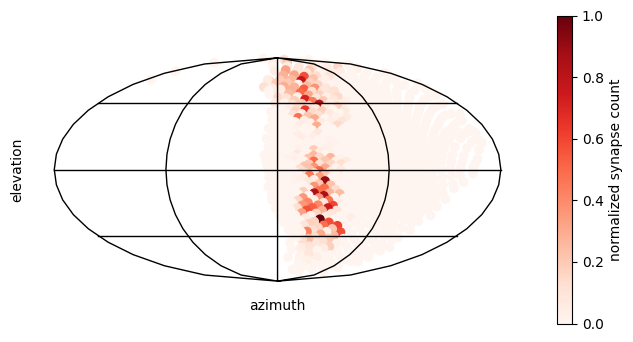

In [24]:
# Molleweide version
fig, ax = plt_mollweide()

ax.scatter(rf_moll['x'].values, rf_moll['y'].values, c=rf_moll['wt'].values, 
            cmap="Reds",vmin=0,vmax=1, )
# add colorbar
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="Reds"), ax=ax)
cbar.set_label('normalized synapse count')

# change size
fig.set_size_inches(8,4)

# title
# ax.set_title(f"RF of {target_inst}_{target_id[i]}")

C:\Users\zhaoa\AppData\Local\Temp\ipykernel_30060\475767218.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


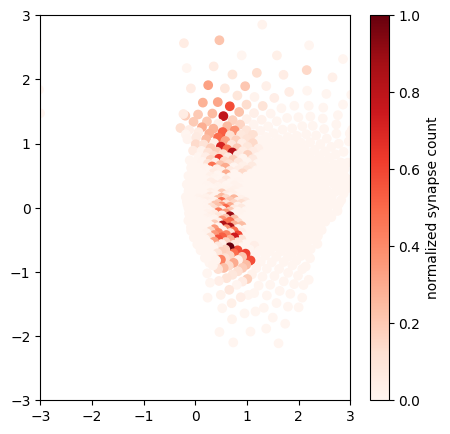

In [25]:
# Mercator version
fig, ax = plt.subplots(nrows=1, ncols=1)

ax.scatter(rf_merc['x'].values, rf_merc['y'].values, c=rf_merc['wt'].values, 
            cmap="Reds",vmin=0,vmax=1)
# add colorbar
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="Reds"), ax=ax)
cbar.set_label('normalized synapse count')

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

# title
# ax.set_title(f"RF of {target_inst}_{target_id[i]}")
# change size
fig.set_size_inches(5,5)

fig.show()

In [ ]:
# save
# fig.savefig(cache_dir / cellname_RF.png")

 # Compute RFs for many cells, if:



 knowing exactly which input cell type/instance to use and how many hops to the target cell



 By default should save in cache -- not sync with git

 ## Example, all "ER4d_R" and construct receptive fields based on all MeTu1 types 2 hops away as inputs.  Slow!

In [ ]:

min_wt = 5 # thrshold edge wt >=
target_type = 'ER4d'
N_hops = 2 # initial hops
# max path length to consider, should be greater than or equal to
layer_N = 4 # set to a large number to include all
roi_source = "ME(R)"

save_dir = PROJECT_ROOT / 'cache' / 'rf' / f'flywire_{target_type}'
save_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
n_target = flywire.search_annotations("^" + target_type + "$")
n_target = n_target[n_target['side'] == "right"]

In [ ]:
target_ids

In [ ]:
target_id
source_id[i]

In [ ]:
id_post = [target_id]
id_upstream = []
for i in range(1):
    n_pre = el_idtype[el_idtype['post_root_id'].isin(id_post)]
    n_pre = n_pre[n_pre['syn_count'] >= wt_threshold]
    id_post = n_pre['pre_root_id'].tolist()
    id_upstream += id_post
    id_upstream = list(set(id_upstream))
n_upstream = classification[classification['root_id'].isin(id_upstream)]

In [ ]:
# n_upstream[n_upstream['cell_type'] == "MeTu1"]
n_upstream

In [ ]:
bodyId = source_id[i]
syntype:str='post'
thr_dist:float=10000
layer_str:str='M5'

In [ ]:
pre_bool = syntype == 'pre'
post_bool = syntype == 'post'
# query synapse data
syn = flywire.get_synapses(bodyId, pre=pre_bool, post=post_bool)
synxyz = syn[[f'{syntype}_x', f'{syntype}_y', f'{syntype}_z']].values
# col xyz
colxyz = pqxyztpind[[f'x_{layer_str}',f'y_{layer_str}',f'z_{layer_str}']].values

# compute the distance matrix
from scipy.spatial import distance
dist = distance.cdist(colxyz, synxyz)
# find the minimum distance for each row
min_dist = np.min(dist, axis=1)
# index of columns that are smaller than the threshold
col_idx = np.where(min_dist < thr_dist)[0]

# assign weights to each col
# find which col_xyz is cloest to each synxyz
# dist = dist[col_idx,:]

In [ ]:
dist

In [ ]:
save_dir = PROJECT_ROOT / 'cache' / 'rf' / f'flywire_{target_type}'
save_dir.mkdir(parents=True, exist_ok=True)

# set up parameters
min_wt = 5 # thrshold edge wt >=
wt_threshold = 5 # thrshold edge wt >=
target_type = 'ER4d'
source_type = 'MeTu1' # need to choose a specific type
layer_str = "M5" # choose which layer to use
N_hops = 2 # initial hops
# max path length to consider, should be greater than or equal to
layer_N = 4 # set to a large number to include all

n_target = flywire.search_annotations("^" + target_type + "$")
n_target = n_target[n_target['side'] == "right"]
target_ids = n_target['root_id'].values

el = el_idtype[['pre_root_id', 'post_root_id', 'syn_count']]
# change column names
el.columns = ['source', 'target', 'weight']


# For each cell, 
# 1/ propagate upstream by N_hops, filter for desired input instances
# 2/ collect all nodes in shortest paths, get adj and transition matrix, compute contribution
# 3/ combine RFs based on contribution weights
# 4/ save plots

for target_id in target_ids: 
    print("target cell:", target_id)
    
    # 1/ propogate upstream by N_hops, filter for desired input cells
    id_post = [target_id]
    id_upstream = []
    for i in range(N_hops):
        n_pre = el_idtype[el_idtype['post_root_id'].isin(id_post)]
        n_pre = n_pre[n_pre['syn_count'] >= wt_threshold]
        id_post = n_pre['pre_root_id'].tolist()
        id_upstream += id_post
        id_upstream = list(set(id_upstream))

    n_upstream = classification[classification['root_id'].isin(id_upstream)]
    # fllter by type and side
    n_upstream = n_upstream[n_upstream['side'] == 'right']
    n_upstream = n_upstream[n_upstream['cell_type'] == source_type]
    n_upstream['cell_type'].value_counts()

    source_id = n_upstream['root_id'].values
    print("cell count for chosen instance:", len(source_id))

    # if no source cells, skip
    if len(source_id) == 0:
        continue

    # 2/ collect all nodes in shortest paths and nbhd
    path_len, paths_all = collect_shortest_paths(source_id, target_id, edgelist=el, min_weight=wt_threshold)
    
    # collect all unique ids from paths_all
    id_path = list(set([item for sublist in paths_all for item in sublist]))
    print("nodes in shortest path:", len(id_path))
    syn_total = el_idtype[el_idtype['post_root_id'].isin(id_path)] \
        .groupby('post_root_id') \
        .agg({'syn_count': 'sum'}) \
        .reindex(id_path) #add missing ids with 0 synapses

    # adj and transition matrix
    adj = flywire.get_adjacency(sources= id_path, targets= id_path)
    # normalize by input
    # divide each row in adj by corresponding row in syn_total
    adj_norm = adj.div(syn_total.loc[adj.columns.values, 'syn_count'], axis=1)
    m = adj_norm.reindex(index=id_path, columns=id_path, fill_value=0)
    # replace nan with 0
    m = m.fillna(0)
    m_adj = m.copy()
    # backward-transition matrix, normalized by row 
    m_trans = m.copy().T

    # propagation
    trans_inf = prop_series_inf(m_trans)
    # trans_long = prop_series(m_trans, 100)
    # normalize by max
    trans_inf = trans_inf / np.max(trans_inf)
    # keep only the ids in id_path
    trans_inf = trans_inf.reindex(index=id_path).reindex(columns=id_path)
    print(trans_inf.shape)

    # initial state with the target as the active node
    v0 = [1 if np.isin(trans_inf.index[i], target_id) else 0 for i in range(len(id_path))]
    # equliibrium state
    contrib = v0 @ trans_inf
    # merge neuron_info on the index of contrib
    contrib.name = 'contribution'
    contrib = pd.merge(contrib, classification[['root_id','cell_type','hemibrain_type', 'side']], left_index=True, right_on='root_id', how='left')
    # replace NaN in cell_type with values from hemibrain_type
    contrib['cell_type'] = contrib['cell_type'].fillna(contrib['hemibrain_type'])
    # change column names
    contrib = contrib.rename(columns = {'root_id':'bodyId'})

    # 3/ combine all RFs based on contribution weights, set weights to 0 if <0

    # Molleweide
    rf_moll = xypq_moll.copy()
    rf_moll['wt'] = 0
    for i in range(len(source_id)):
        cw = contrib[contrib['bodyId'] == source_id[i]]['contribution']
        if len(cw) > 0:
            cw = cw.clip(lower=0).values[0]
            pqw = pqw_columnar_flywire(source_id[i], layer_str=layer_str) # use the appriroate layer
            df2 = pd.merge(xypq_moll, pqw, on=['p', 'q'], how='left')
            df2['wt'] = df2['wt'].fillna(0)
            df2['wt'] = df2['wt'] * cw
            rf_moll['wt'] = rf_moll['wt'] + df2['wt']
    rf_moll['wt'] = rf_moll['wt'] / rf_moll['wt'].max()


    # Mercator
    rf_merc = rf_moll.copy()
    rf_merc[['x','y']] = xypq_merc[['x','y']]

    # 4/ save plots

    # Molleweide version
    fig, ax = plt_mollweide()
    ax.scatter(rf_moll['x'].values, rf_moll['y'].values, c=rf_moll['wt'].values, 
                cmap="Reds",vmin=0,vmax=1, )
    # add colorbar
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="Reds"), ax=ax)
    cbar.set_label('normalized synapse count')
    # # change size
    # fig.set_size_inches(16,8)
    # title
    ax.set_title(f"RF {target_type}_{target_id} Molleweide")

    # save fig
    fig.savefig(Path(save_dir, f"RF_{target_type}_{target_id}_Moll.png"))
    plt.close(fig) # close fig to avoid memory leak

    # Mercator version
    fig, ax = plt_mercator()
    ax.scatter(rf_merc['x'].values, rf_merc['y'].values, c=rf_merc['wt'].values, 
                cmap="Reds",vmin=0,vmax=1, )
    # add colorbar
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap="Reds"), ax=ax)
    cbar.set_label('normalized synapse count')
    # # change size
    # fig.set_size_inches(16,8)
    # title
    ax.set_title(f"RF {target_type}_{target_id} Mercator")

    # save fig
    fig.savefig(Path(save_dir, f"RF_{target_type}_{target_id}_Merc.png"))
    plt.close(fig) # close fig to avoid memory leak




# DEBUG, ignore below

## 3d plot

In [ ]:
syn = flywire.get_synapses(source_id[0], pre=False)
sk = flywire.get_skeletons(source_id[0])

In [ ]:
# # plot 3d
# fig_n = navis.plot3d(
#     sk,
#     soma=False,
#     color='black', linewidth=2,
#     inline=False, backend='plotly')

# fig_col = px.scatter_3d(xyzpq,
#     x='x', y='y', z='z',
#     title=('med col'),
#     hover_name='bodyId',
#     hover_data=['p', 'q'])

# fig_col.update_traces(marker_size = 6, marker={"color":"gray"}, opacity=0.2)

# fig_mesh = navis.plot3d(
#     [ME_R, LO_R, LOP_R]
#     , color=['yellow','yellow','grey']
#     , alpha=0.2
#     , inline=False
#     , backend='plotly')

# fig = go.Figure(data= fig_col.data + fig_n.data + fig_mesh.data)

# fig.update_layout(autosize=False, width=900, height=600)
# fig.update_layout(margin={"l":0, "r":0, "b":0, "t":0})

# fig.show()

## Get col xyz for the relevant layer, and incoming connection xyz the source neurons

In [ ]:
syn = flywire.get_synapses(source_id[0], pre=False, post=True)
synxyz = syn[['post_x', 'post_y', 'post_z']].values

In [ ]:
# use M5 coordinates
colxyz = pqxyztpind[['x_M5','y_M5','z_M5']].values

## compute distance to select col, and assign weights

In [ ]:
# compute the shortest distance from each col_xyz to all synxyz, if it's smaller than a threshold, keep it
# if not, discard it
from scipy.spatial import distance

# threshold distance
dist_thr = 10000

# compute the distance matrix
dist = distance.cdist(colxyz, synxyz)

# find the minimum distance for each row
min_dist = np.min(dist, axis=1)

# index of columns that are smaller than the threshold
col_idx = np.where(min_dist < dist_thr)[0]

In [ ]:
# find which col_xyz is cloest to each synxyz
# compute the distance matrix
# dist = distance.cdist(colxyz[col_idx,:], synxyz)
dist = dist[col_idx,:]

# find the minimum distance for each colum
min_dist = np.min(dist, axis=0)
# remove columns with min_dist > dist_thr
dist = dist[:, min_dist < dist_thr]

# find the index of the minimum distance for each column
min_idx = np.argmin(dist, axis=0)

# value count min_idx, sort by index
wts = pd.Series(min_idx).value_counts().sort_index()

# make an array with wts, wts.index as row numbers, fill missing rows with 0
wt_arr = np.zeros(len(col_idx))
wt_arr[wts.index] = wts.values

In [ ]:
# combine pqxyztpind[['p','q']] and wt_arr
pqw = np.concatenate((pqxyztpind[['p','q']].values[col_idx], wt_arr[:,None]), axis=1)
# convert to df and change type to int, rename columns
pqw = pd.DataFrame(pqw, columns=['p','q','wt'])
pqw = pqw.astype({'p': int, 'q': int, 'wt': int})

### determine dist threshold

In [ ]:
# range of min_dist
plt.figure(figsize=(5, 2))
plt.hist(min_dist, bins=200)
plt.xlim(0, 25000)
plt.show()

In [ ]:
# 3d plot
fig_col = go.Figure(data=[go.Scatter3d(
    x=colxyz[:, 0], y=colxyz[:, 1], z=colxyz[:, 2], mode='markers',
    marker=dict(size=5, color='black', opacity=0.8)
)])

fig_syn = go.Figure(data=[go.Scatter3d(
    x=synxyz[:, 0], y=synxyz[:, 1], z=synxyz[:, 2], mode='markers',
    marker=dict(size=5, color='blue', opacity=0.8)
)])

fig = go.Figure(data= fig_col.data + fig_syn.data)

fig.update_layout(autosize=False, width=600, height=400)
fig.update_layout(margin={"l":0, "r":0, "b":0, "t":0})
fig.show()

In [ ]:
np.sqrt((764876-769342)**2+(358916-365883)**2+(178000-174325)**2)